In [25]:
import pandas as pd

DATA_PATH = "../data/japanese_news.csv"

df = pd.read_csv(DATA_PATH, sep="\t")

print("Rows:", len(df))
print(df.head())

/var/folders/sc/ytp3g0vj4mdbsfqr4zyn9pnc0000gn/T/ipykernel_81833/2041196340.py:5: DtypeWarning: Columns (0: title, 1: author) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, sep="\t")


Rows: 312955
          source        date title author  \
0  kobe-np.co.jp  2005-07-01   NaN    NaN   
1  kobe-np.co.jp  2005-07-01   NaN    NaN   
2  kobe-np.co.jp  2007-04-07   NaN    NaN   
3  kobe-np.co.jp  2007-04-07   NaN    NaN   
4  kobe-np.co.jp  2007-04-07   NaN    NaN   

                                                text  
0  会見した北口寛人市長は「刑事訴訟で被告となっている職員にはそれぞれ主張があるが、組織全体とし...  
1  明石・歩道橋事故をめぐる民事訴訟で、神戸地裁から計五億六千八百万円の賠償を命じられた兵庫県（...  
2  会見後、遺族代理人の渡部吉泰弁護士は「裁判長が『問うべき者を問わないのは正義に反する』とはっ...  
3           遺族会は、雑踏警備本部長を務めた元明石署長ら二人の起訴を求め、活動を続けている。  
4  五人の遺族が閉廷後に会見。二女の優衣菜ちゃん＝当時（８つ）＝を亡くした三木清さん（３８）＝姫...  


In [26]:
# preprocessed
df = df[df["text"].notnull() & (df["text"].str.strip() != "")].copy()
print("Rows with non-empty text:", len(df))

df["char_len"] = df["text"].str.len()
print(df["char_len"].describe())

Rows with non-empty text: 312954
count    312954.000000
mean        102.669881
std          58.882429
min           1.000000
25%          66.000000
50%          99.000000
75%         133.000000
max        5066.000000
Name: char_len, dtype: float64


In [27]:
from collections import Counter
sample_text = "\n".join(df["text"])
# preprocessed freq
char_counts = Counter("".join(df["text"]))
i=1
for ch, c in char_counts.most_common(100):
    print(f'Rank {i}: {repr(ch)}, {c}')
    i+=1

Rank 1: 'の', 1023191
Rank 2: '、', 841868
Rank 3: '。', 705084
Rank 4: 'た', 691813
Rank 5: 'に', 636673
Rank 6: 'を', 603051
Rank 7: 'い', 563467
Rank 8: 'し', 542402
Rank 9: 'は', 535823
Rank 10: 'と', 530330
Rank 11: 'が', 512111
Rank 12: 'る', 510597
Rank 13: 'で', 495140
Rank 14: 'て', 407929
Rank 15: 'な', 385223
Rank 16: 'ー', 366059
Rank 17: 'か', 281300
Rank 18: 'っ', 267256
Rank 19: '１', 259989
Rank 20: 'れ', 247426
Rank 21: '）', 236005
Rank 22: '（', 235943
Rank 23: 'ン', 231814
Rank 24: 'ら', 230590
Rank 25: '「', 218401
Rank 26: '」', 218398
Rank 27: 'も', 215013
Rank 28: 'す', 211645
Rank 29: '日', 210417
Rank 30: '２', 202409
Rank 31: 'り', 199593
Rank 32: '０', 188170
Rank 33: 'う', 178772
Rank 34: 'ま', 162048
Rank 35: 'さ', 155015
Rank 36: 'こ', 147398
Rank 37: 'ス', 143890
Rank 38: 'ル', 141430
Rank 39: 'ト', 138473
Rank 40: 'き', 137614
Rank 41: 'だ', 135771
Rank 42: '３', 132108
Rank 43: 'く', 129526
Rank 44: '年', 126018
Rank 45: 'ん', 125482
Rank 46: '大', 124491
Rank 47: 'け', 120537
Rank 48: 'め', 117331


In [28]:
from fugashi import Tagger

tagger = Tagger()  

STOPWORDS = {
    # generic 動詞
    "する", "いる", "ある", "なる", "できる", "くる", "いく",

    # generic 名詞
    "こと", "ところ", "もの", "よう", "ため", "とき",

    # 時間漢字
    "年", "月", "日",

    # ひらがな
    "あ", "い", "う", "え", "お", "か", "き", "く", "け", "こ", "さ", "し", "す", "せ", "そ", "た", "ち", "つ", "て", "と", "な", "に", "ぬ", "ね", "の", "は", "ひ", "ふ", "へ", "ほ", "ま", "み", "む", "め", "も", "や", "ゆ", "よ", "ら", "り", "る", "れ", "ろ", "わ", "を", "ん",

    # カタカナ
    "ア", "イ", "ウ", "エ", "オ", "カ", "キ", "ク", "ケ", "コ", "サ", "シ", "ス", "セ", "ソ", "タ", "チ", "ツ", "テ", "ト", "ナ", "ニ", "ヌ", "ネ", "ノ", "ハ", "ヒ", "フ", "ヘ", "ホ", "マ", "ミ", "ム", "メ", "モ", "ヤ", "ユ", "ヨ", "ラ", "リ", "ル", "レ", "ロ", "ワ", "ヲ", "ン",

    # 特別 
    "%", "。", "ー", "・", "％"
}

def tokenize(text):
    tokens = []
    for word in tagger(text):
        surface = word.surface           
        pos1 = word.feature.pos1         
        #  content words only

        if surface.isdigit() or surface in STOPWORDS:
            continue

        if pos1 in ["名詞", "動詞", "形容詞"]:
            tokens.append(surface)
    return tokens

df["tokens"] = df["text"].apply(tokenize)

In [29]:
for i in range(len(df["tokens"].head(20))):
    print(df["tokens"].iloc[i])

['会見', '北口', '寛人', '市長', '刑事', '訴訟', '被告', 'なっ', '職員', 'それぞれ', '主張', '組織', '全体', '判決', '厳しく', '受け止め', '述べ', '原告', '下村', '誠治', '神戸', '市', '垂水', '区', '同席', '県', '判決', '受け止め', '訴え']
['明石', '歩道', '事故', 'めぐる', '民事', '訴訟', '神戸', '地裁', '五', '億', '六千', '八百', '万', '円', '賠償', '命じ', '兵庫', '県', '県', '警備', '会社', 'シカン', 'エヌ', 'ケイ', 'セキュリティ', '三', 'うち', '明石', '市', '三十', '控訴', '表明']
['会見', '遺族', '代理', '渡部', '吉', '泰', '弁護', '裁判', '問う', '者', '問わ', '正義', '反する', '述べ', '検察', '起訴', '独占', '主義', '警鐘', '鳴らす', '画期', '評価']
['遺族', '会', '雑踏', '警備', '本部', '務め', '元', '明石', '二人', '起訴', '求め', '活動', '続け']
['五', '遺族', '閉廷', '会見', '二女', '優衣', '菜', '当時', '亡くし', '三木', '清', '姫路', '市', '被告', '四', '当事', '雑踏', '事故', '再発', '防止', '活動', '携わっ', 'ほしい', '謝罪', 'つながる']
['弁護', '側', 'よる', '四', '被告', 'うち', '金沢', '被告', '上告', '意思', '示し', 'いう', '川口', '洋光', '大月', '美佳']
['苦しみ', '悲しみ', '一生', '消え', 'ずさん', '警備', '多数', '死傷', '出', '明石', '歩道', '事故', '控訴', '判決', '六', '大阪', '高裁', '警察', '明石', '市', '警備', '会社', '被告', '四', '一', '有罪', '判決', '言い渡さ', '裁判', 

In [30]:
# cleaned size
df["char_len"] = df["text"].str.len()
df["token_len"] = df["tokens"].str.len()

print(df[["char_len", "token_len"]].describe())

            char_len      token_len
count  312954.000000  312954.000000
mean      102.669881      25.893777
std        58.882429      16.094761
min         1.000000       0.000000
25%        66.000000      16.000000
50%        99.000000      25.000000
75%       133.000000      34.000000
max      5066.000000    1610.000000


In [31]:
from collections import Counter

# cleaned freq

all_tokens = [t for doc in df["tokens"] for t in doc]
token_counts = Counter(all_tokens)

for token, cnt in token_counts.most_common(30):
    print(token, cnt)

市 58553
日本 47759
いう 42275
県 35929
円 33395
なっ 30772
万 27944
会 26101
ない 24661
よる 24043
時 23125
回 22794
町 19690
同 18726
つい 17950
前 17743
東京 17654
一 16827
選手 16202
分 15463
世界 14330
震災 13887
あり 13864
人 13205
でき 13039
あっ 12871
大会 12871
東 12675
発表 12537
受け 12142


In [32]:
# top sources
top_sources = df["source"].value_counts().head(3).index

for s in top_sources:
    tokens_source = [t for doc in df.loc[df["source"] == s, "tokens"].head(2000) for t in doc]
    print("Source:", s)
    for token, cnt in Counter(tokens_source).most_common(20):
        print(" ", token, cnt)
    print()

Source: mainichi.jp
  支持 676
  自民 600
  民主 552
  選挙 518
  層 518
  区 467
  市 343
  割 335
  候補 279
  投票 261
  政権 233
  県 231
  前 210
  いう 184
  党 179
  衆院 178
  前回 176
  当選 176
  新人 166
  万 164

Source: sankei.jp.msn.com
  日本 422
  いう 404
  ない 275
  なっ 228
  県 228
  よる 209
  市 202
  震災 176
  中国 175
  つい 175
  東京 153
  原発 152
  学校 140
  問題 133
  機 127
  受け 127
  福島 126
  被災 117
  会 116
  朝鮮 113

Source: nikkei.com
  いう 534
  投資 387
  企業 359
  日本 352
  会社 313
  金融 296
  取引 288
  円 264
  なっ 253
  市場 253
  株式 225
  銀行 216
  ない 206
  価格 198
  携帯 182
  開発 172
  経済 169
  株 167
  資金 166
  米 161



In [33]:
# just looking at the tokens to understand
for i in range(3):
    print("==== Article", i, "====")
    print(df["text"].iloc[i][:200])   
    print(df["tokens"].iloc[i][:40])   

==== Article 0 ====
会見した北口寛人市長は「刑事訴訟で被告となっている職員にはそれぞれ主張があるが、組織全体として判決を厳しく受け止めた」と述べた。原告団長の下村誠治さん（４６）＝神戸市垂水区＝も同席。「県警も判決を真摯（しんし）に受け止めて」と訴えた。
['会見', '北口', '寛人', '市長', '刑事', '訴訟', '被告', 'なっ', '職員', 'それぞれ', '主張', '組織', '全体', '判決', '厳しく', '受け止め', '述べ', '原告', '下村', '誠治', '神戸', '市', '垂水', '区', '同席', '県', '判決', '受け止め', '訴え']
==== Article 1 ====
明石・歩道橋事故をめぐる民事訴訟で、神戸地裁から計五億六千八百万円の賠償を命じられた兵庫県（県警）、警備会社ニシカン（現エヌ・ケイ・セキュリティ）など三者のうち、明石市が三十日、控訴しないことを正式に表明した。
['明石', '歩道', '事故', 'めぐる', '民事', '訴訟', '神戸', '地裁', '五', '億', '六千', '八百', '万', '円', '賠償', '命じ', '兵庫', '県', '県', '警備', '会社', 'シカン', 'エヌ', 'ケイ', 'セキュリティ', '三', 'うち', '明石', '市', '三十', '控訴', '表明']
==== Article 2 ====
会見後、遺族代理人の渡部吉泰弁護士は「裁判長が『問うべき者を問わないのは正義に反する』とはっきり述べたのは、検察の起訴独占主義に警鐘を鳴らす画期的なことだ」と評価した。
['会見', '遺族', '代理', '渡部', '吉', '泰', '弁護', '裁判', '問う', '者', '問わ', '正義', '反する', '述べ', '検察', '起訴', '独占', '主義', '警鐘', '鳴らす', '画期', '評価']


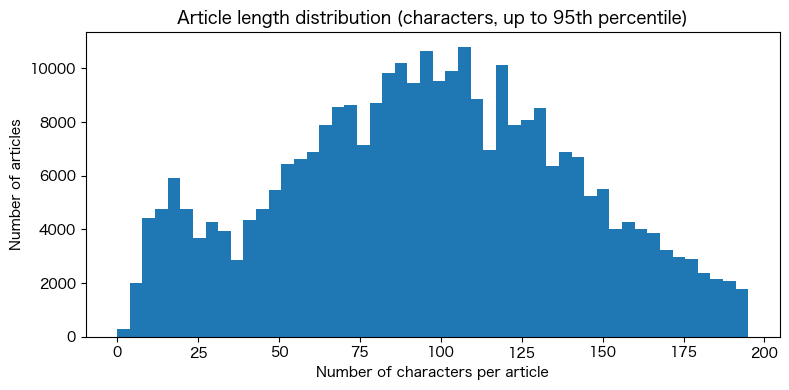

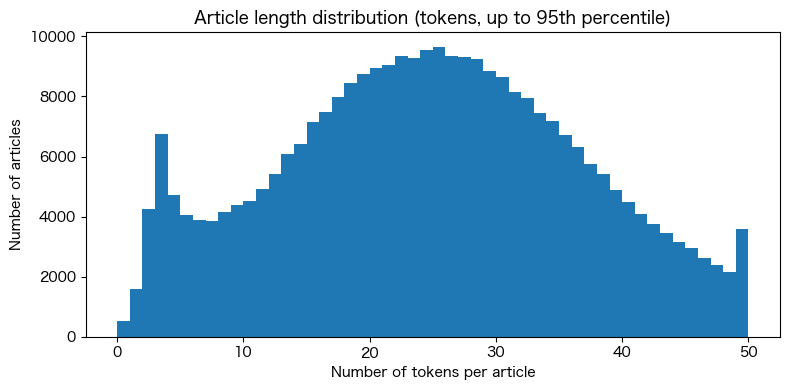

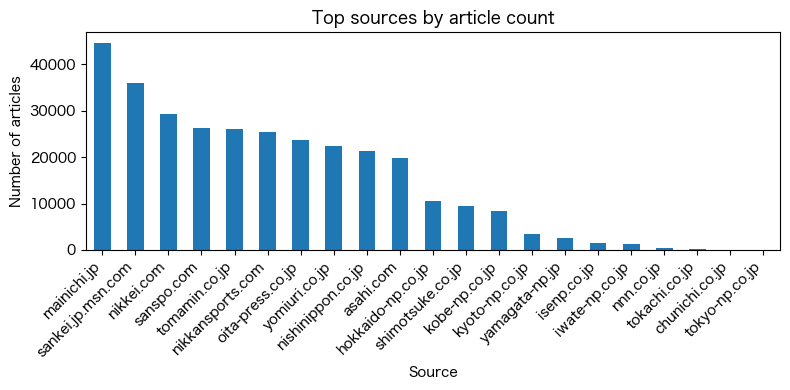

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# graphs

df["char_len"] = df["text"].str.len()
char_p95 = np.percentile(df["char_len"], 95)

plt.figure(figsize=(8, 4))
plt.hist(df["char_len"], bins=50, range=(0, char_p95))
plt.xlabel("Number of characters per article")
plt.ylabel("Number of articles")
plt.title("Article length distribution (characters, up to 95th percentile)")
plt.tight_layout()
plt.show()


df["token_len"] = df["tokens"].str.len()
tok_p95 = np.percentile(df["token_len"], 95)

plt.figure(figsize=(8, 4))
plt.hist(df["token_len"], bins=50, range=(0, tok_p95))
plt.xlabel("Number of tokens per article")
plt.ylabel("Number of articles")
plt.title("Article length distribution (tokens, up to 95th percentile)")
plt.tight_layout()
plt.show()


source_counts = df["source"].value_counts().head(30)

plt.figure(figsize=(8, 4))
source_counts.plot(kind="bar")
plt.xlabel("Source")
plt.ylabel("Number of articles")
plt.title("Top sources by article count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

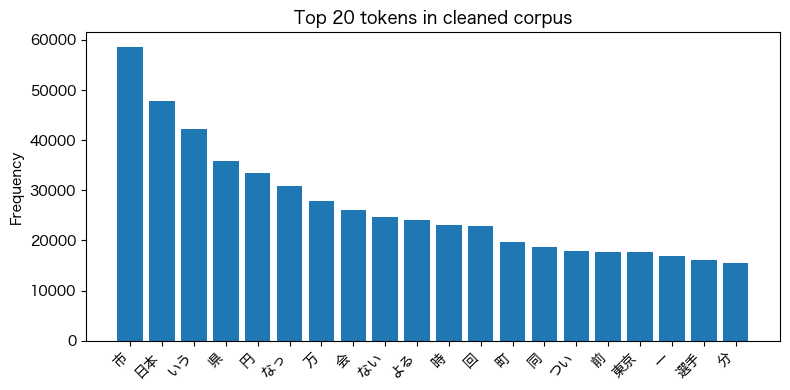

In [35]:
from collections import Counter
import matplotlib.pyplot as plt

all_tokens = [t for doc in df["tokens"] for t in doc]

token_counts = Counter(all_tokens)
top_tokens = token_counts.most_common(20)  

if top_tokens:
    tokens, counts = zip(*top_tokens)

    plt.figure(figsize=(8, 4))
    plt.bar(range(len(tokens)), counts)
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
    plt.ylabel("Frequency")
    plt.title("Top 20 tokens in cleaned corpus")
    plt.tight_layout()
    plt.show()

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
docs_for_clustering = [" ".join(tokens) for tokens in df["tokens"]]

vectorizer = TfidfVectorizer(
    token_pattern=r"[^ ]+",  
    max_features=5000,        
    min_df=10,                 
    max_df=0.5                
)

X = vectorizer.fit_transform(docs_for_clustering)
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5566945 stored elements and shape (312954, 5000)>

cluster
0    162766
1      7870
2     13730
3     38244
4      4795
5     35291
6     32268
7     17990
Name: count, dtype: int64


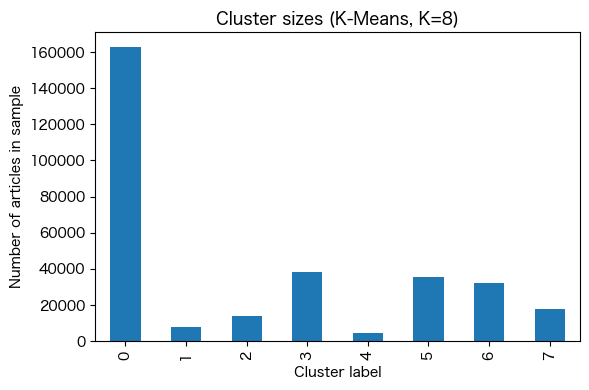

In [37]:
from sklearn.cluster import KMeans

K = 8

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df["cluster"] = labels

cluster_counts = df["cluster"].value_counts().sort_index()
print(cluster_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster label")
plt.ylabel("Number of articles in sample")
plt.title("Cluster sizes (K-Means, K=8)")
plt.tight_layout()
plt.show()

Fitting KMeans with K=2...
Fitting KMeans with K=3...
Fitting KMeans with K=4...
Fitting KMeans with K=5...
Fitting KMeans with K=6...
Fitting KMeans with K=7...
Fitting KMeans with K=8...
Fitting KMeans with K=9...
Fitting KMeans with K=10...
Fitting KMeans with K=11...
Fitting KMeans with K=12...
Fitting KMeans with K=13...
Fitting KMeans with K=14...


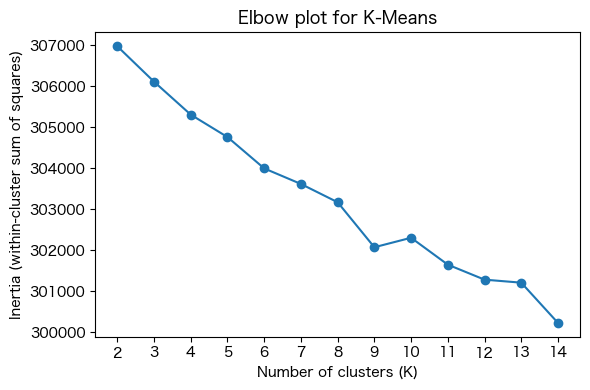

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Ks = range(2, 15) 
inertias = []

for k in Ks:
    print(f"Fitting KMeans with K={k}...")
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)              
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(Ks), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow plot for K-Means")
plt.xticks(list(Ks))
plt.tight_layout()
plt.show()

In [40]:
import numpy as np

terms = np.array(vectorizer.get_feature_names_out())
order_centroids = kmeans.cluster_centers_.argsort(axis=1)[:, ::-1]

for c in range(K):
    top_terms = terms[order_centroids[c, :30]]
    print(f"Cluster {c}")
    print("Top terms:", ", ".join(top_terms))
    print()

for c in range(K):
    print(f"Cluster {c}  top sources")
    print(df.loc[df["cluster"] == c, "source"].value_counts().head(5))
    print()

Cluster 0
Top terms: いう, ない, なっ, 無, 人, よる, あり, 前, 一, 話し, でき, 同, あっ, 東京, 見, いい, 自分, メートル, なく, 中, なり, 時間, 世界, 発表, 会社, 町, 会, 部, 今, 米

Cluster 1
Top terms: 時, 午後, 午前, 分, ごろ, 半, 時間, 市, 同, よる, 無料, 問い合わせ, 町, 円, 電話, 区, 県, 会, 入場, 前, 男性, いう, 東京, メートル, 同日, 日本, あっ, 行わ, 紙面, キロ

Cluster 2
Top terms: 円, 万, 億, ドル, 銭, 市場, 兆, 価格, ユーロ, 年度, ．, 台, 比, 額, 販売, 同, よる, 平均, 増, 東京, 取引, 総額, なっ, 事業, 前日, 市, 減, 期, いう, 発表

Cluster 3
Top terms: 原発, 首相, 会, つい, 政府, 民主, 委員, 事故, 電力, 問題, 政権, 原子, 経済, 案, 自民, 福島, 述べ, 知事, 安全, 大統領, 示し, 選挙, ない, 議員, 会議, 政治, 方針, 県, 協議, 国民

Cluster 4
Top terms: 容疑, 逮捕, 疑い, 捜査, 市, 県, よる, 違反, 区, 同署, 事件, 女性, 認め, ごろ, 警視, 課, いう, 法, 供述, 無職, 会社, 男性, 円, 現金, 調べ, 万, 殺害, 男, 時, 自宅

Cluster 5
Top terms: 回, 選手, 大会, 試合, 決勝, 出場, 優勝, 監督, チーム, 点, リーグ, 日本, 野球, 秒, 勝, 世界, 分, 女子, 初, 五輪, 男子, 高校, 代表, 安打, 今季, 予選, 投手, 連続, なっ, 共同

Cluster 6
Top terms: 市, 県, 町, 会, 苫小牧, 区, 福島, よる, 大阪, 学校, 開か, 村, 千歳, 市民, 同市, 参加, 避難, いう, なっ, 市長, センター, 地, 同, 宮城, 部, 地域, 福岡, 府, 京都, 万

Cluster 7
Top terms: 日本, 震災, 東, 被災, 地, 復興, 県, 西, 支援, 新聞, いう, 市, な